#### Simulate different synthetic signals (sinusoids, square waves, impulses, …).
##### • Compute DFT and analyze frequencies.
##### • Test the different properties of the DFT (linearity, time-shifting, …).
##### • Review the effect of different sampling rates on the DFT.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def dft(signal: np.ndarray) -> np.ndarray:
    N = len(signal)
    zeta = np.exp(complex(0, -2 * pi / N))

    s_f = []
    for f in range(N):
        s_f_n = np.sum(signal * np.power(zeta, f * np.arange(N)))
        s_f.append(s_f_n)

    return np.array(s_f)

def time_plot(signal: np.ndarray):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(signal)
    ax = plt.xlabel('time')
    plt.tight_layout()
    plt.show()


def spectral(signal: np.ndarray, fs) -> None:
    N = len(signal)

    dft_result = dft(signal)
    psd = (abs(dft_result)**2) / N

    freqs = np.arange(N) * fs / N

    half_N = N // 2 + 1

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(psd[:half_N])
    ax = plt.xlabel('frequency [Hz]')
    ax.label={'x': 'Frequency (Hz)', 'y': 'Power Spectral Density'}
    plt.show()



#### Sinusoids

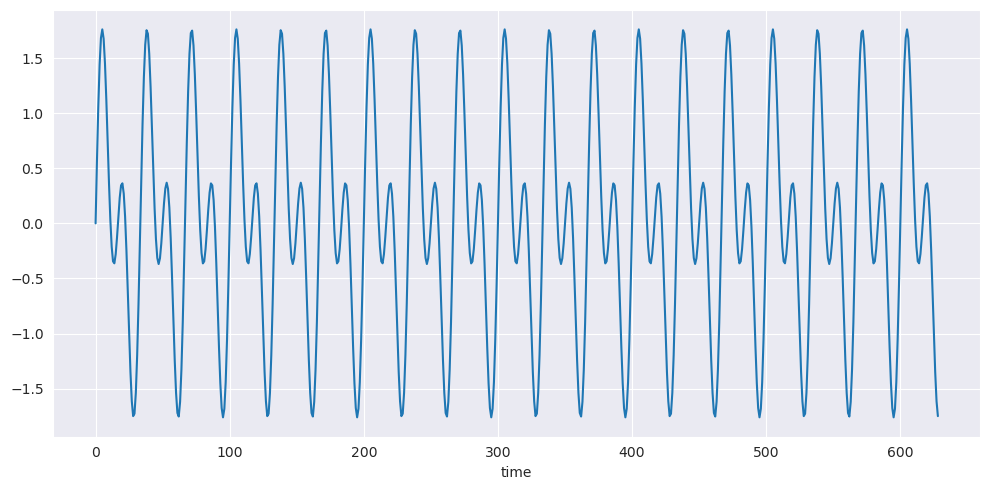

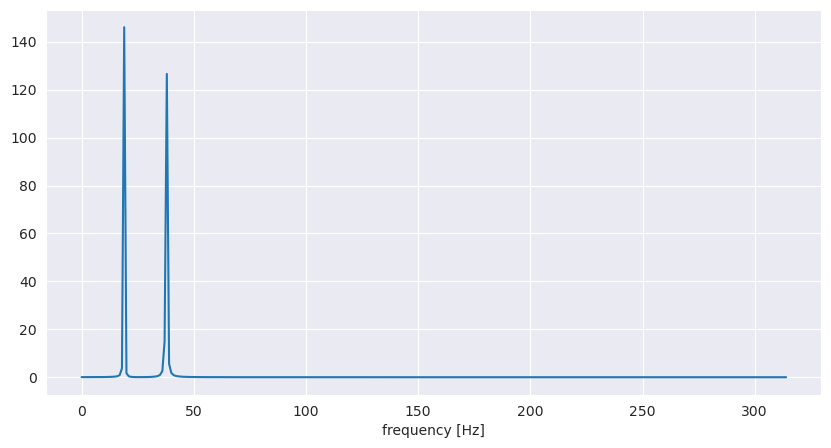

In [3]:
pi = np.pi

time = np.arange(0, 2*pi, 0.01)

signal1 = 1 * np.sin( 2*pi*3 * time + 0)
signal2 = 1 * np.sin( 2*pi*6 * time + 0)

signal = signal1 + signal2

time_plot(signal)
spectral(signal, 12)

#### Square Wave

In [4]:
def square_wave(time: np.ndarray, freq: float, amplitude: float = 1.0, phase: float = 0.0) -> np.ndarray:
    return amplitude * np.sign(np.sin(2 * np.pi * freq * time + phase))

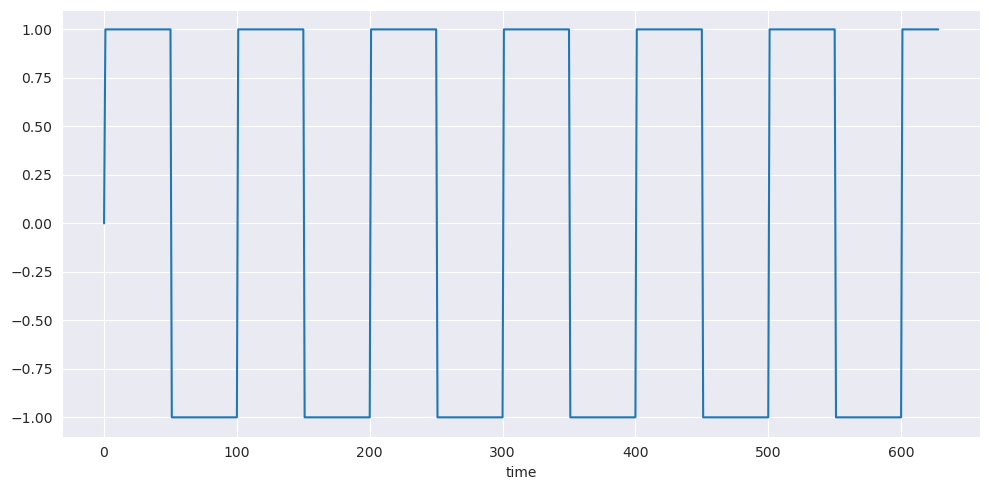

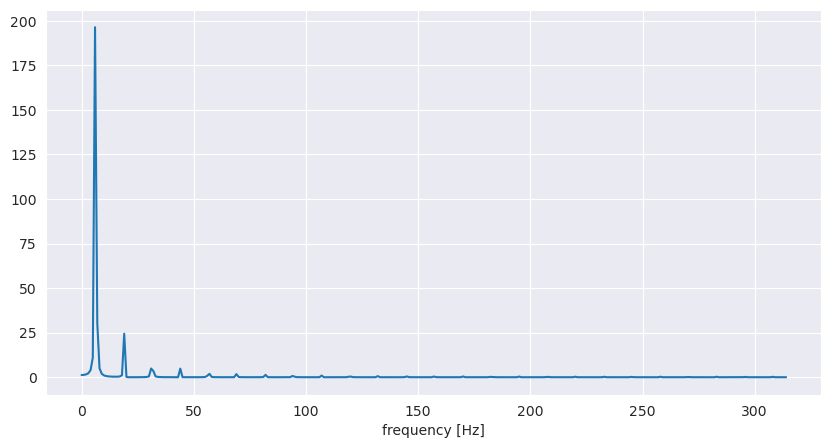

In [5]:
time_plot(square_wave(time, 1, amplitude=1, phase=0))
spectral(square_wave(time, 1.0), 100)


### Impulse functions

In [6]:
def impulse(n: int, N: int) -> np.ndarray:
    x = np.zeros(N)
    if 0 <= n < N:
        x[n] = 1.0
    return x

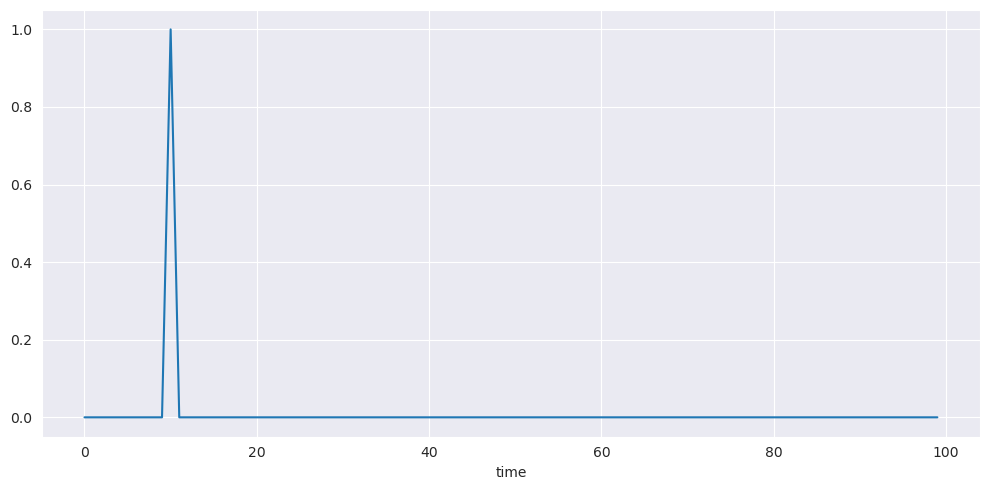

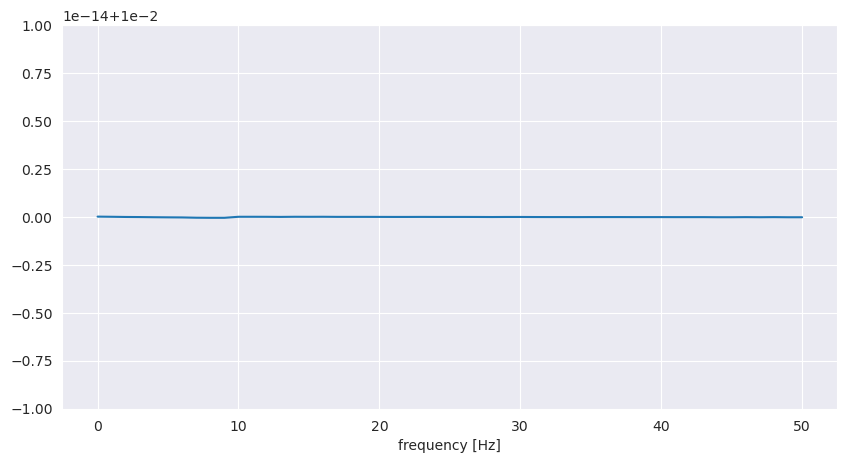

In [7]:
imp = impulse(n=10, N=100)
time_plot(imp)
spectral(imp, 10)

# Model real-world time series
- Fit sinusoids with known frequencies.

In [8]:
from dataset import get_power_consumption
from utils import plot_fft

In [9]:
df = get_power_consumption()
df.head()

,consumptions(kWh)
time,
2011-12-31 23:15:00+00:00,33620.2025
2011-12-31 23:30:00+00:00,33255.9075
2011-12-31 23:45:00+00:00,32924.2950
2012-01-01 00:00:00+00:00,32730.2850
2012-01-01 00:15:00+00:00,32487.0300


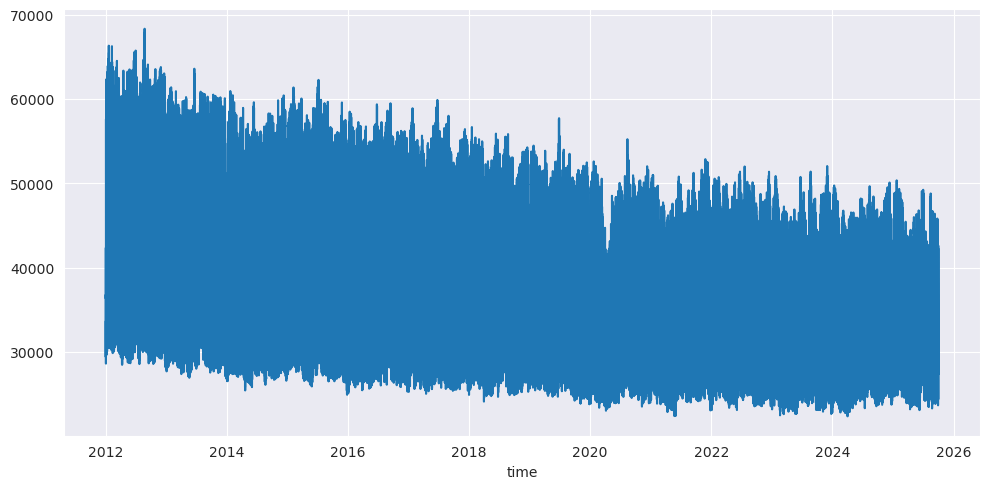

In [10]:
time_plot(df['consumptions(kWh)'])

In [11]:
t = np.array([i for i in range(len(df.index))])
y = df['consumptions(kWh)']

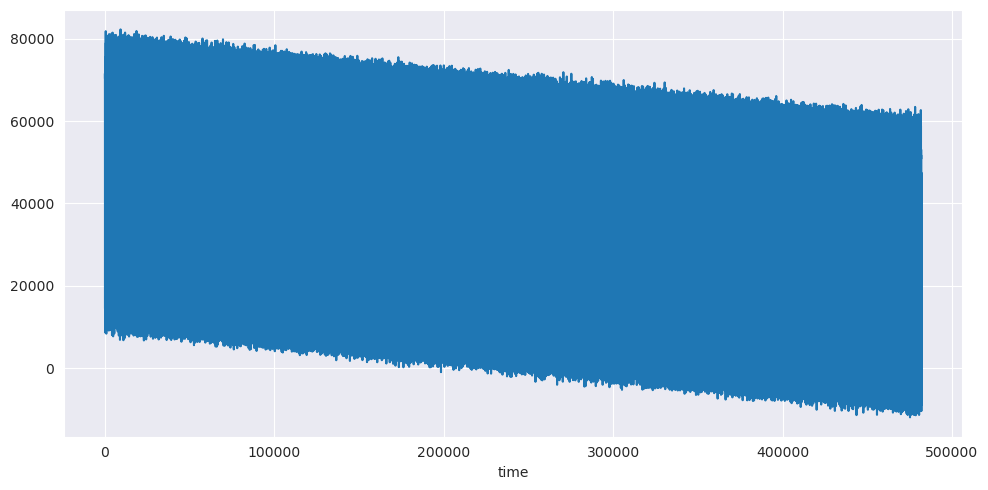

In [12]:
# Frequencies in cycles per sample
f_daily = 1 / 96
f_weekly = 1 / 672
f_yearly = 1 / 35040

period_d = 96
period_w = 672
period_y = 35040

a_0 = np.sum(y[0:period_w])/ period_w
np.random.seed(32)
noise = np.random.normal(0, 1000, len(y))
noise0 = np.random.normal(0, 1000, len(y))
# Amplitudes and phases (just as examples)
A_daily =  600 * np.sum(y[0:period_d] * np.sin(2 * np.pi * (len(y))*f_daily * np.arange(0, period_d) )) / period_d + noise
A_weekly =  2000 * np.sum(y[0:period_w] * np.sin(2 * np.pi * (len(y))*f_weekly * np.arange(0, period_w) )) / period_w + noise
A_yearly =  2 * np.sum(y[0:period_y] * np.sin(2 * np.pi * (len(y))*f_yearly * np.arange(0, period_y) )) / period_y  + noise0
phi_daily = np.pi/2
phi_weekly = 0
phi_yearly = 0

# Sinusoidal value at timestamp t
y_t =  (a_0 - 0.04148 *t ) + (( A_daily * np.sin(2 * np.pi * f_daily * t + phi_daily)) +
(A_weekly * np.sin(2 * np.pi * f_weekly * t + phi_weekly) ) +
(A_yearly * np.sin(2 * np.pi * f_weekly * t + phi_yearly)  ))

time_plot(y_t)


- Compute DFT and analyze dominant frequencies.

In [13]:
np.fft.fft(y[0:period_w])

array([ 3.02460031e+07+0.00000000e+00j, -1.72807301e+06+7.33656255e+05j,
       -9.38211451e+05+5.61142661e+05j, -1.65907832e+05+4.29368461e+05j,
        3.45770579e+05+3.22400532e+05j,  7.38596444e+05+1.52550949e+05j,
        9.76234703e+05+1.98393010e+05j, -3.44578591e+06+2.19385978e+06j,
        6.00744115e+05-1.74209482e+05j,  3.38698682e+05-1.24895399e+05j,
        7.07397712e+04-1.33853737e+05j, -1.00158158e+05-1.29123329e+05j,
       -1.17717048e+05-1.36559706e+05j,  3.70069819e+03-2.82651198e+05j,
       -1.37075243e+05+1.03034281e+06j,  8.97855626e+04-2.32696456e+05j,
        4.56631063e+04-9.60563068e+04j, -1.18527566e+04+2.09793495e+04j,
       -5.20629752e+04+4.68824110e+03j, -1.04439393e+05+2.79569241e+04j,
       -2.01085358e+05+1.07597749e+05j,  2.48835950e+05-5.09161388e+05j,
       -7.19216220e+04+1.41057477e+05j, -4.19682252e+04+6.41647502e+04j,
        4.15893985e+04-9.84821350e+03j,  2.76512145e+04+2.53958016e+04j,
       -5.54126008e+03+4.14620102e+04j,  1.98908760

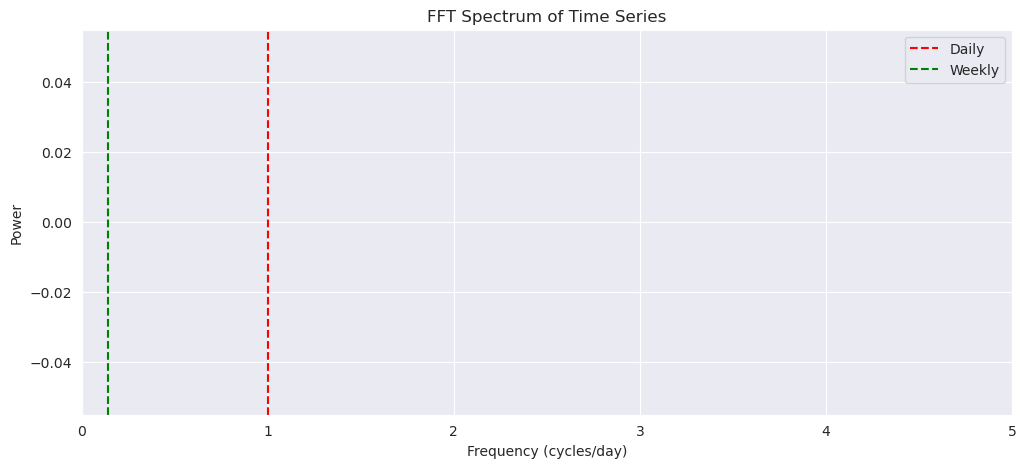

In [14]:
y = df['consumptions(kWh)'].values
n = len(y)

dt = 15 * 60

# FFT
Y = np.fft.fft(y)
Y = Y[:n//2]  # positive frequencies

freq = np.fft.fftfreq(n, d=dt)
freq = freq[:n//2]

freq_cpd = freq * 24 * 60 * 60

# Power spectrum
power = np.abs(Y)**2 / n

# Plot
plt.figure(figsize=(12,5))
plt.plot(freq_cpd, power, color='blue')
plt.xlabel('Frequency (cycles/day)')
plt.ylabel('Power')
plt.title('FFT Spectrum of Time Series')
plt.xlim(0, 5)
daily_freq = 1
weekly_freq = 1/7
plt.axvline(daily_freq, color='red', linestyle='--', label='Daily')
plt.axvline(weekly_freq, color='green', linestyle='--', label='Weekly')
plt.legend()
plt.show()